# **(ADD THE NOTEBOOK NAME HERE)**

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Fraud-Analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Fraud-Analysis'

In [4]:
# Load the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
# Load the cleaned dataset in
df = pd.read_csv('Dataset/CleanData/cleaned_fraud_dataset.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 50000 rows, 20 columns


,Transaction_ID,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label,hour,day_of_week
0,TXN_33553,39.79,POS,93213.17,Laptop,Sydney,Travel,0,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0,19,Monday
1,TXN_9427,1.19,Bank Transfer,75725.25,Mobile,New York,Clothing,0,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1,4,Wednesday
2,TXN_199,28.96,Online,1588.96,Tablet,Mumbai,Restaurants,0,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1,15,Tuesday
3,TXN_12447,254.32,ATM Withdrawal,76807.20,Tablet,New York,Clothing,0,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1,0,Thursday
4,TXN_39489,31.28,POS,92354.66,Mobile,Mumbai,Electronics,1,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1,23,Saturday


### Set colours for graphs


In [7]:
sns.set_style('whitegrid')

fraud_colors = {0: '#4C72B0', 1: '#C44E52'}  # blue = genuine, red = fraud — used consistently in every chart

## Class Balance

A polished view of how many transactions are fraudulent vs genuine with percentage labels for clarity.

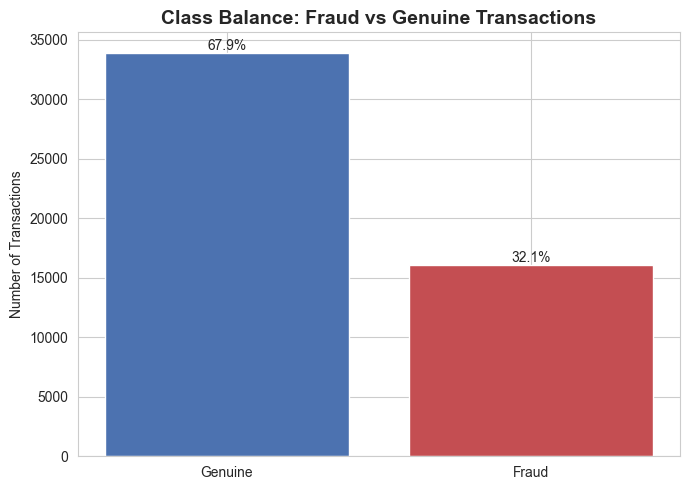

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = df['Fraud_Label'].value_counts()
bars = ax.bar(['Genuine', 'Fraud'], counts.values, color=[fraud_colors[0], fraud_colors[1]])
ax.set_title('Class Balance: Fraud vs Genuine Transactions', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Transactions')

ax.bar_label(bars, labels=[f'{c/len(df)*100:.1f}%' for c in counts.values])

plt.tight_layout()
plt.show()

# H1: Failed Transactions - Visualisations

A box plot comparing Failed_Transaction_Count_7d between fraud and genuine transactions. This helps visually confirm the difference found in the EDA t-test, by showing the spread and median of failed transactions for each group side by side.

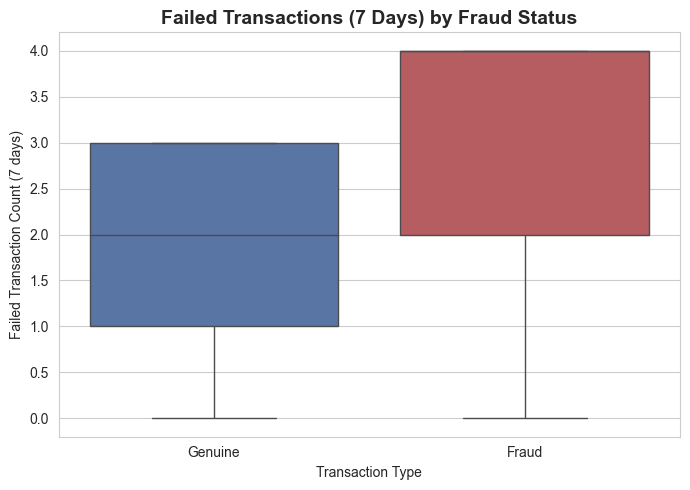

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(x='Fraud_Label', y='Failed_Transaction_Count_7d', data=df,
            hue='Fraud_Label', palette=fraud_colors, legend=False, ax=ax)
ax.set_title('Failed Transactions (7 Days) by Fraud Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Transaction Type')
ax.set_ylabel('Failed Transaction Count (7 days)')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Genuine', 'Fraud'])
plt.tight_layout()

plt.show()

The box plot shows thar fraudulent transactions tend to have a noticeably higher number of failed attempts in the past 7 days than genuine transactions, confirming the statistically significant result found in the EDA notebook p < 0.001.

A supporting bar chart to show fraud rate at each failed-transaction-count level to see whether fraud risk increases steadily or jumps sharply as failed attempts rise.

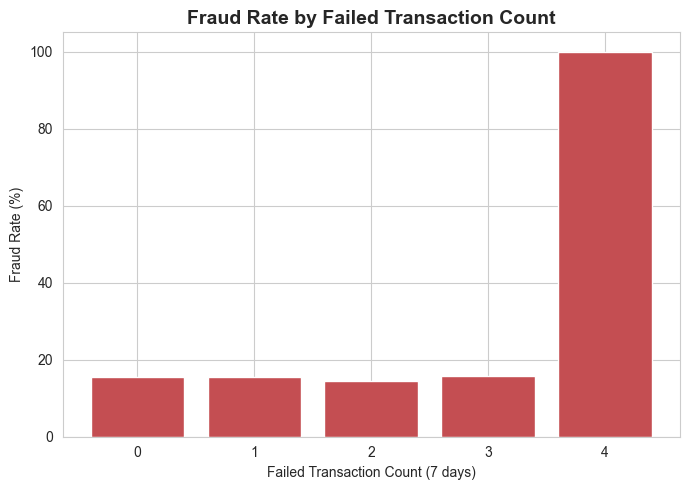

In [15]:
fraud_rate = df.groupby('Failed_Transaction_Count_7d')['Fraud_Label'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(fraud_rate.index, fraud_rate.values, color=fraud_colors[1])
ax.set_title('Fraud Rate by Failed Transaction Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Failed Transaction Count (7 days)')
ax.set_ylabel('Fraud Rate (%)')
plt.tight_layout()

plt.show()

This graph shows fraud rate stays fairly flat around 15% for failed transaction counts of 0 to 3 then jumps dramatically to 100% at exactly 4 failed transactions. This suggests 4 failed transactions in 7 days acts almost like a hard cutoff in this dataset  any account reaching that threshold is fraudulent every time, making it an extremely strong  rule for flagging risk.

The graphs help support H1 the box plot shows fraudulent transactions generally have more failed attempts on average, while the bar chart reveals this isn't a gradual trend. fraud rate stays roughly flat until exactly 4 failed transactions, at which point every transaction in the dataset is fraudulent. This gives H1 stronger practical value than the t-test result alone suggests since it points to a specific number and should implement action after 3 failed transactions.

# H2: Risk Score - Visualisations

A box plot comparing Risk_Score between fraud and genuine transactions. This helps visually confirm the difference found in the EDA t-test by showing the spread and median of risk score for each group side by side.

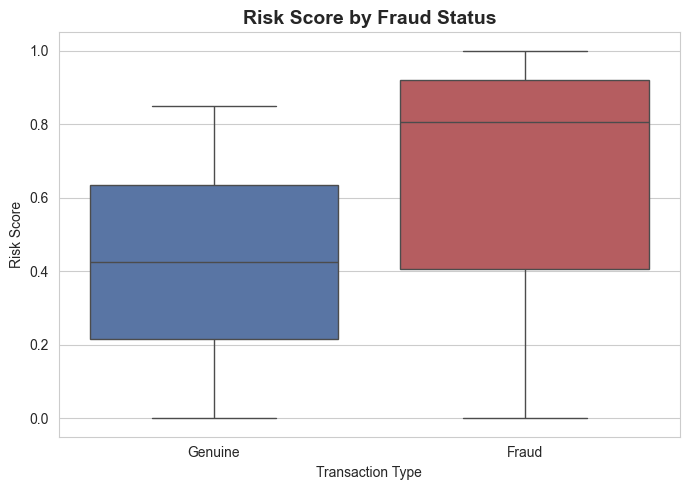

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(x='Fraud_Label', y='Risk_Score', data=df,
            hue='Fraud_Label', palette=fraud_colors, legend=False, ax=ax)
ax.set_title('Risk Score by Fraud Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Transaction Type')
ax.set_ylabel('Risk Score')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Genuine', 'Fraud'])
plt.tight_layout()

plt.show()

This chart shows fraudulent transactions tend to have a noticeably higher risk score than genuine transactions confirming the statistically significant result found in the EDA notebook p < 0.001.

I also done a histogram to show the distribution of Risk_Score for each group to see the overall shape rather than just the summary box plot.

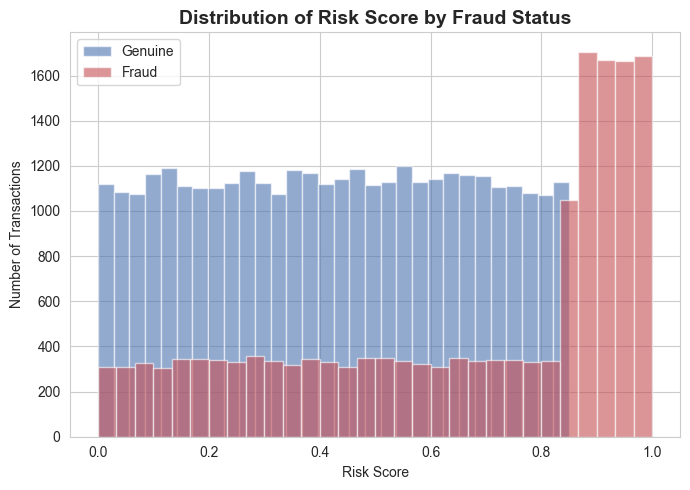

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df[df['Fraud_Label']==0]['Risk_Score'], bins=30, alpha=0.6, label='Genuine', color=fraud_colors[0])
ax.hist(df[df['Fraud_Label']==1]['Risk_Score'], bins=30, alpha=0.6, label='Fraud', color=fraud_colors[1])
ax.set_title('Distribution of Risk Score by Fraud Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Risk Score')
ax.set_ylabel('Number of Transactions')
ax.legend()
plt.tight_layout()

plt.show()

This shows genuine transactions cluster mostly below a risk score of 0.65 while the fraudulent transactions are more spread out and weighted toward the higher end, with a notable concentration near 0.8–0.9. Genuine transactions also cap out at 0.85, whereas fraud reaches the full range up to 1.0 

Both the charts support H2: the box plot confirms fraud transactions have a higher risk score on average, while the histogram shows genuine transactions never exceed 0.85, meaning any transaction scoring above that threshold is fraud every time in this dataset. 

# H4: Transaction Type - Visualisation

A bar chart showing fraud rate % across each transaction type to see whether any type stands out as riskier than the others.

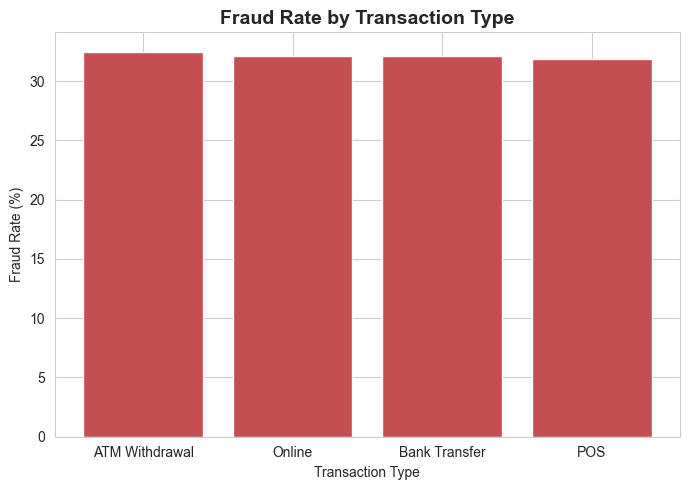

In [19]:
fraud_rate = df.groupby('Transaction_Type')['Fraud_Label'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(fraud_rate.index, fraud_rate.values, color=fraud_colors[1])
ax.set_title('Fraud Rate by Transaction Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Transaction Type')
ax.set_ylabel('Fraud Rate (%)')
plt.tight_layout()

plt.show()

This chart shows fraud rate is almost identical across all four transaction types. This confirms the chi-square result from the EDA notebook that transaction type has no  influence on fraud  in this dataset.

# H5: Location - Visualisation

A bar chart showing fraud rate % across each location to see whether any city stands out as riskier than the others.

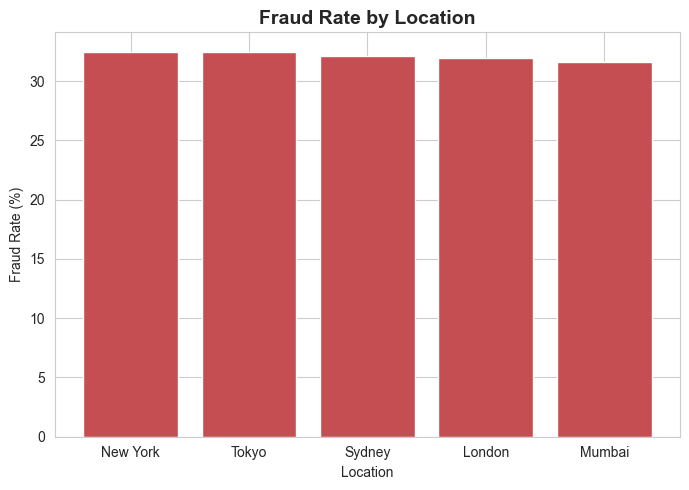

In [20]:
fraud_rate = df.groupby('Location')['Fraud_Label'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(fraud_rate.index, fraud_rate.values, color=fraud_colors[1])
ax.set_title('Fraud Rate by Location', fontsize=14, fontweight='bold')
ax.set_xlabel('Location')
ax.set_ylabel('Fraud Rate (%)')
plt.tight_layout()

plt.show()

The bar shows fraud rate is almost identical across all five locations. This confirms the chi-square result from the EDA notebook that location has no influence on fraud risk in this dataset.

# H6: Time Patterns - Visualisation

These small charts side by side showing fraud rate by hour, weekend status, and day of week. Since all three came back non-significant in the EDA notebook, I've grouped them into one figure instead of three separate large charts, so it's easy to see there's no real time-based pattern across any of them.

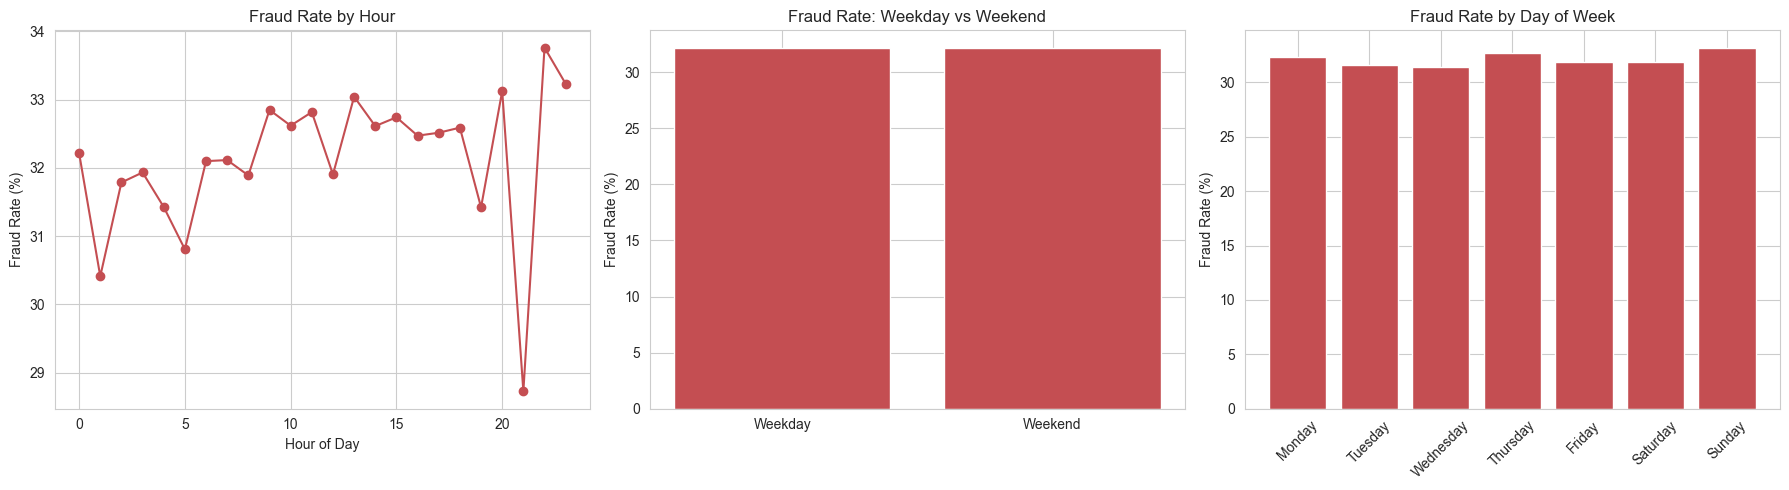

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hourly = df.groupby('hour')['Fraud_Label'].mean() * 100
axes[0].plot(hourly.index, hourly.values, color=fraud_colors[1], marker='o')
axes[0].set_title('Fraud Rate by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate (%)')

weekend = df.groupby('Is_Weekend')['Fraud_Label'].mean() * 100
axes[1].bar(['Weekday', 'Weekend'], weekend.values, color=fraud_colors[1])
axes[1].set_title('Fraud Rate: Weekday vs Weekend')
axes[1].set_ylabel('Fraud Rate (%)')

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('day_of_week')['Fraud_Label'].mean().reindex(day_order) * 100
axes[2].bar(daily.index, daily.values, color=fraud_colors[1])
axes[2].set_title('Fraud Rate by Day of Week')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.show()

The first chart shows fraud rate by hour stays fairly flat throughout the day with a slight dip at hour 21 and a slight peak at hour 22. These are the most extreme points but the overall range is still narrow so this doesn't represent a meaningful pattern.

The second chart shows almost no difference between weekday and weekend fraud rates. 

The third chart shows fraud rate by day of week practically the same with no day standing out as noticeably riskier. 

Together these confirm the EDA results none of these time based factors are useful signals for fraud detection in this dataset, 

# Correlation Matrix

This Heatmap with show how all the numeric features relate to Fraud_Label at once

In [22]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation = numeric_df.corr()['Fraud_Label'].sort_values(ascending=False)
correlation

Fraud_Label                     1.000000
Failed_Transaction_Count_7d     0.509871
Risk_Score                      0.385810
hour                            0.005822
Transaction_Amount              0.001901
Avg_Transaction_Amount_7d       0.000703
Is_Weekend                      0.000064
Transaction_Distance           -0.000116
Previous_Fraudulent_Activity   -0.000718
Card_Age                       -0.003120
Account_Balance                -0.003153
Daily_Transaction_Count        -0.007065
Name: Fraud_Label, dtype: float64

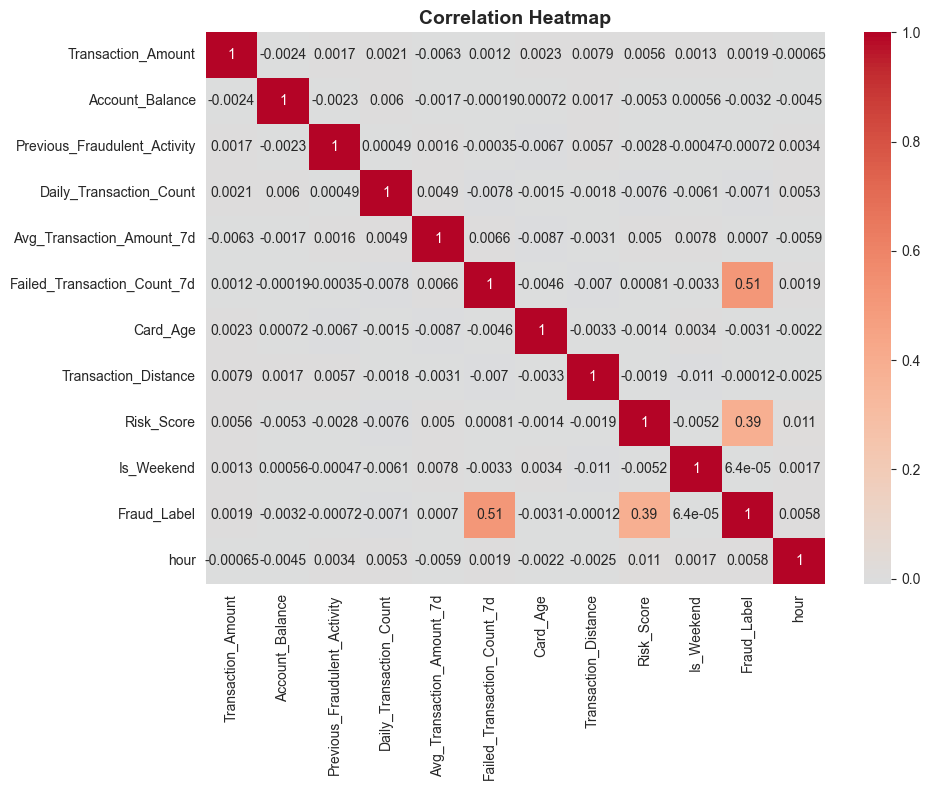

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

The heatmap shows that Risk_Score and Failed_Transaction_Count_7d show a stronger correlation with Fraud_Label than any other numeric feature while variables like hour and Is_Weekend show almost no correlation at all.

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [6]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)